# CMNIST offline empirical-base study

This notebook loads the completed offline run and compares independent and OT correction at their validation-selected best and final checkpoints.

The run uses one fixed set of 20,000 independently generated observational rows (not paired colors), batch size 128, Gaussian base noise with standard deviation 0.1, 100,000 nuisance updates, and 200,000 updates for each target flow. The target plug-in reservoir is refreshed every 10,000 completed updates. Best checkpoints are selected on a fixed 512-sample-per-arm validation draw and compared with the final 200k checkpoints on a separate shared 5,000-sample-per-arm test draw.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision.utils import make_grid

_here = Path.cwd().resolve()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "deconfoundingfm").exists())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from deconfoundingfm.experimental import load_result_bundle

RESULT_DIR = Path(os.environ.get(
    "CMNIST_OFFLINE_RESULT_DIR",
    REPO_ROOT / "examples" / "cmnist" / "results" / "offline",
)).resolve()
bundle = load_result_bundle(RESULT_DIR)
config = bundle["config"]
print("Result directory:", RESULT_DIR)
print("Evaluation samples per arm:", config["eval_n"])
print(
    "Study:", config["study_mode"],
    "| observations:", config["observational_n"], config["observational_design"],
    "| batch:", config["batch_size"],
    "| nuisance/target updates:", config["nuisance_steps"], config["target_steps"],
    "| base noise std:", config["base_noise_std"],
    "| reservoir refresh:", config["plugin_reservoir_update_frequency"],
)
print("Saved bundle keys:", sorted(bundle))


Result directory: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/offline
Evaluation samples per arm: 5000
Study: offline_empirical | observations: 20000 iid_observational | batch: 128 | nuisance/target updates: 100000 200000 | base noise std: 0.1 | reservoir refresh: 10000
Saved bundle keys: ['color_diagnostics', 'color_values', 'config', 'convergence', 'data_manifest', 'manifest', 'metrics', 'model_manifest', 'path', 'samples', 'trajectories', 'trajectory_summary']


## Final sliced-Wasserstein metrics

SW2 is computed separately for each treatment arm and then averaged. Every method uses the same random projection directions.


In [2]:
metrics = bundle["metrics"]
selection = metrics["checkpoint_selection"]
rows = [{"method": "Uncorrected source", "checkpoint": "--", "SW2": metrics["source_sw2"]}]
for method, label in (("decfm", "Independent"), ("ot", "OT")):
    rows.extend([
        {
            "method": f"{label} (validation-selected best)",
            "checkpoint": selection[method]["best_step"],
            "SW2": selection[method]["test_best_sw2"],
        },
        {
            "method": f"{label} (final)",
            "checkpoint": selection[method]["final_step"],
            "SW2": selection[method]["test_final_sw2"],
        },
    ])
display(pd.DataFrame(rows))
print(
    "Independent test n per arm:", metrics["evaluation_n_per_arm"],
    "| SW2 projections:", metrics["sw2_projections"],
)


,method,checkpoint,SW2
0,Uncorrected source,--,0.031244
1,Independent (validation-selected best),200000,0.010051
2,Independent (final),200000,0.010051
3,OT (validation-selected best),125000,0.010673
4,OT (final),200000,0.011209


Independent test n per arm: 5000 | SW2 projections: 256


## Generated samples

The compact panel shows the qualitative comparison needed for the study. Each row uses 16 saved plotting examples; learned rows use each method's validation-selected best checkpoint.


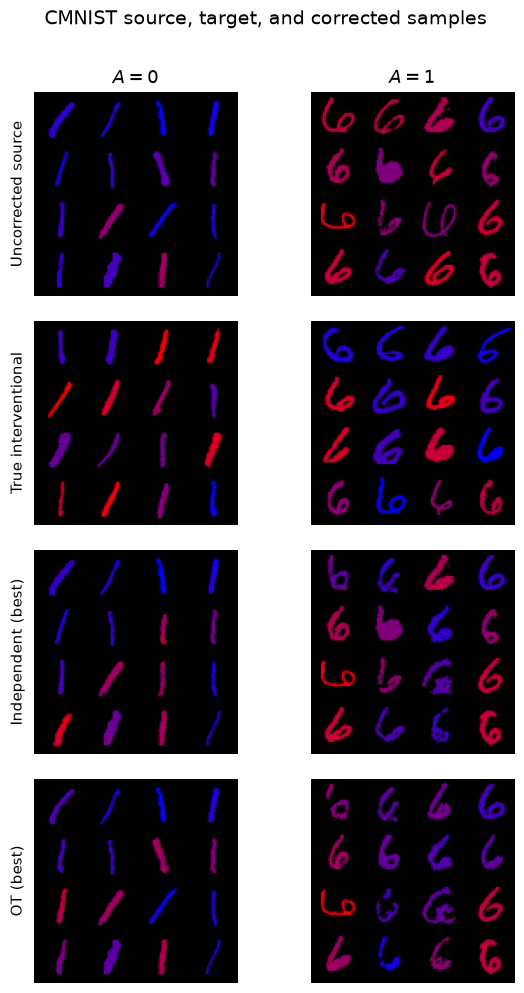

In [3]:
samples = bundle["samples"]

sample_rows = (
    ("Uncorrected source", "observed"),
    ("True interventional", "true"),
    ("Independent (best)", "decfm_best"),
    ("OT (best)", "ot_best"),
)

fig, axes = plt.subplots(len(sample_rows), 2, figsize=(7, 11))
for row, (label, key_prefix) in enumerate(sample_rows):
    for arm, ax in enumerate(axes[row]):
        images = samples[f"{key_prefix}_a{arm}"][:16].clamp(0, 1)
        grid = make_grid(images, nrow=4, padding=1).permute(1, 2, 0).cpu()
        ax.imshow(grid)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"$A={arm}$", fontsize=13)
    axes[row, 0].text(
        -0.08,
        0.5,
        label,
        rotation=90,
        va="center",
        ha="center",
        transform=axes[row, 0].transAxes,
        fontsize=11,
    )
fig.suptitle("CMNIST source, target, and corrected samples", fontsize=14, y=0.995)
plt.subplots_adjust(top=0.92, wspace=0.04, hspace=0.12)
plt.show()


## Validation SW2 and checkpoint selection

Every point uses the same deterministic 512-image truth set and the same noised base batch in each arm, with common projection directions. The starred minimum selects the stored best checkpoint for that method. Best and final are subsequently compared on a separate 5,000-per-arm test draw.


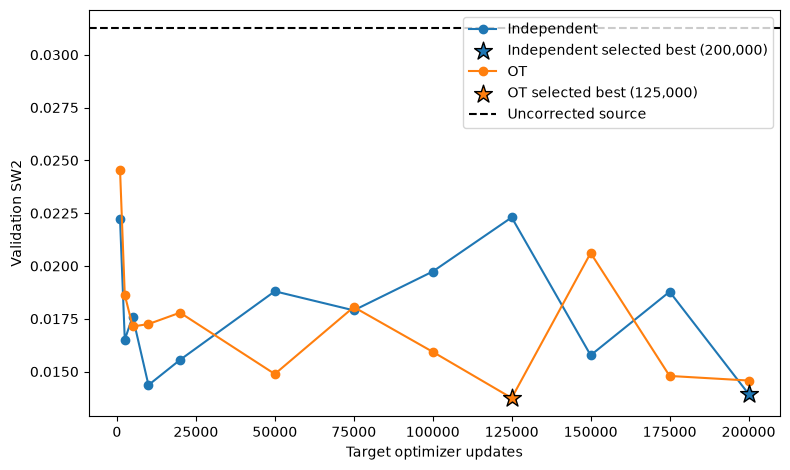

In [4]:
convergence = bundle["convergence"]
plt.figure(figsize=(8, 4.8))
colors = {"decfm": "tab:blue", "ot": "tab:orange"}
labels = {"decfm": "Independent", "ot": "OT"}
for method in ("decfm", "ot"):
    plt.plot(
        convergence["steps"],
        convergence[method],
        marker="o",
        color=colors[method],
        label=labels[method],
    )
    best_step = int(convergence["best_step_by_method"][method])
    best_index = convergence["steps"].index(best_step)
    plt.scatter(
        [best_step],
        [convergence[method][best_index]],
        marker="*",
        s=180,
        color=colors[method],
        edgecolor="black",
        zorder=5,
        label=f"{labels[method]} selected best ({best_step:,})",
    )
plt.axhline(metrics["source_sw2"], linestyle="--", color="black", label="Uncorrected source")
plt.xlabel("Target optimizer updates")
plt.ylabel("Validation SW2")
plt.legend()
plt.tight_layout()
plt.show()


## Learned color distributions \(P(X(a))\)

As in the paper, image color is recovered as \(R/(R+B)\) and displayed on the logit scale. Because the true color variable is \(X\sim\mathrm{Uniform}(0,1)\), its logit has the exact standard logistic density shown in black. Each method panel overlays that target with \(\hat p(X(0))\) and \(\hat p(X(1))\) from its validation-selected best checkpoint.


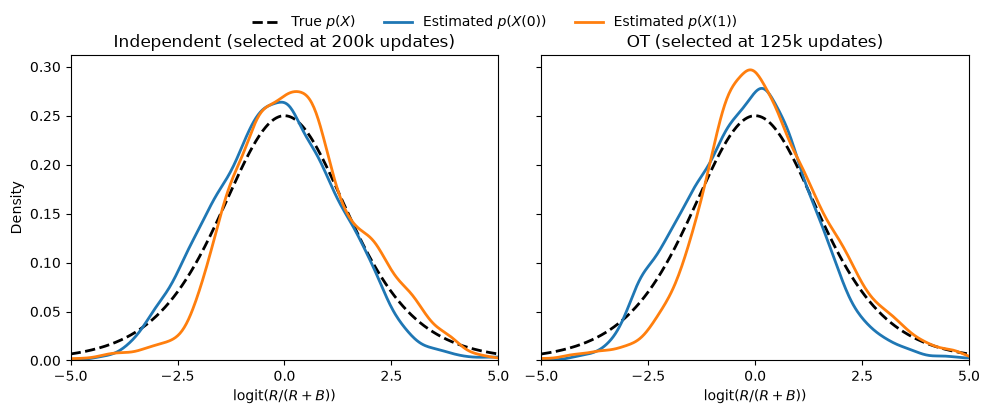

In [5]:
color_values = bundle["color_values"]

def logit_kde(values, grid):
    values = values[torch.isfinite(values)].float().clamp(1e-5, 1 - 1e-5)
    logits = torch.logit(values)
    std = float(logits.std(unbiased=False))
    q25, q75 = torch.quantile(logits, torch.tensor([0.25, 0.75]))
    robust_std = float((q75 - q25) / 1.349)
    positive_scales = [scale for scale in (std, robust_std) if scale > 0]
    scale = min(positive_scales) if positive_scales else 1.0
    bandwidth = max(0.9 * scale * len(logits) ** (-0.2), 0.12)
    standardized = (grid[:, None] - logits[None, :]) / bandwidth
    return (
        torch.exp(-0.5 * standardized.square()).mean(dim=1)
        / (bandwidth * (2 * torch.pi) ** 0.5)
    )

logit_grid = torch.linspace(-5, 5, 400)
sigmoid_grid = torch.sigmoid(logit_grid)
true_density = sigmoid_grid * (1 - sigmoid_grid)
methods = (
    ("decfm", "decfm_best", "Independent"),
    ("ot", "ot_best", "OT"),
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, (method, sample_key, label) in zip(axes, methods):
    ax.plot(
        logit_grid,
        true_density,
        color="black",
        linestyle="--",
        linewidth=2,
        label=r"True $p(X)$",
    )
    for arm, color in ((0, "tab:blue"), (1, "tab:orange")):
        density = logit_kde(color_values[sample_key][f"arm{arm}"], logit_grid)
        ax.plot(
            logit_grid,
            density,
            color=color,
            linewidth=2,
            label=rf"Estimated $p(X({arm}))$",
        )
    best_step = metrics["checkpoint_selection"][method]["best_step"]
    ax.set_title(f"{label} (selected at {best_step / 1000:g}k updates)")
    ax.set_xlabel(r"$\operatorname{logit}(R/(R+B))$")
    ax.set_xlim(-5, 5)
    ax.set_xticks([-5, -2.5, 0, 2.5, 5])
axes[0].set_ylim(bottom=0)
axes[0].set_ylabel("Density")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.04))
plt.tight_layout()
plt.show()


## Flow-change and path diagnostics

The saved trajectory diagnostics use the final 200k correction states. A shared batch of 512 base images per arm receives Gaussian base noise and is transformed by both methods. Endpoint change is measured only over foreground pixels identified from the corresponding clean source digit, so background noise does not define the mask. Full trajectories are retained for the top- and bottom-changing examples.


In [6]:
trajectory_summary = bundle["trajectory_summary"]
rows = []
for method in ("decfm", "ot"):
    rows.append({"method": method, **trajectory_summary[method]["average_over_arms"]})
display(pd.DataFrame(rows))


,method,mean_foreground_pixel_change,mean_path_length,mean_endpoint_displacement,mean_straightness_ratio,mean_bar_E_v,mean_bar_E_vdot,dimension,n_trajectories_per_arm
0,decfm,0.113628,0.160515,0.115314,1.463744,0.027170,1.573503,2352,512
1,ot,0.118764,0.132776,0.113337,1.195120,0.018262,0.556119,2352,512


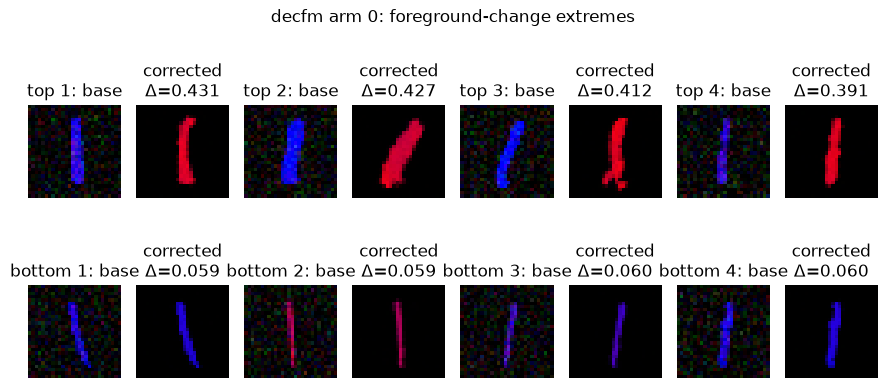

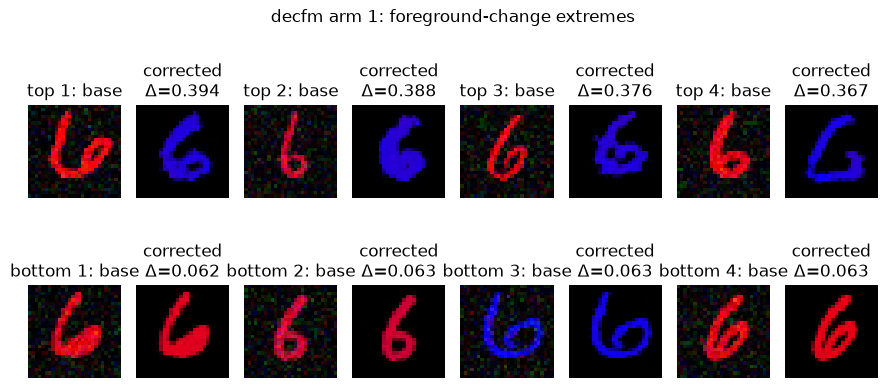

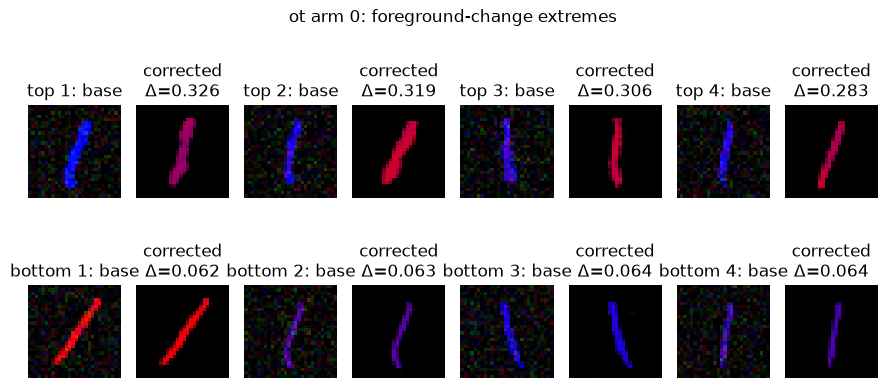

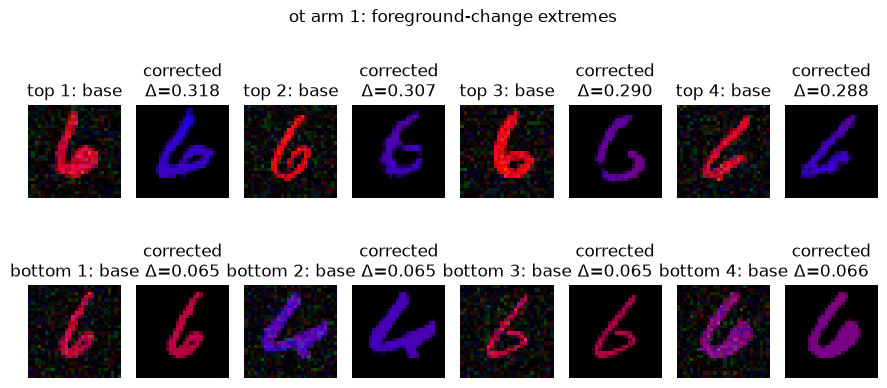

In [7]:
trajectories = bundle["trajectories"]

def show_change_extremes(method, arm, keep=4):
    record = trajectories[method][f"arm{arm}"]
    fig, axes = plt.subplots(2, 2 * keep, figsize=(2.2 * keep, 4.5))
    for row, extreme in enumerate(("top", "bottom")):
        selected = record[extreme]
        sequence = selected["trajectory"]
        scores = selected["foreground_pixel_change"]
        for j in range(min(keep, sequence.shape[1])):
            axes[row, 2*j].imshow(sequence[0, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j].set_title(f"{extreme} {j+1}: base")
            axes[row, 2*j+1].imshow(sequence[-1, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j+1].set_title(f"corrected\nΔ={scores[j]:.3f}")
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(f"{method} arm {arm}: foreground-change extremes")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    for arm in (0, 1):
        show_change_extremes(method, arm)


## Selected full trajectories

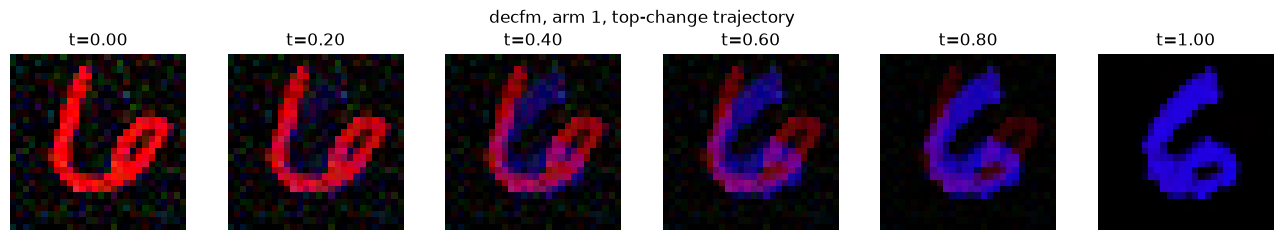

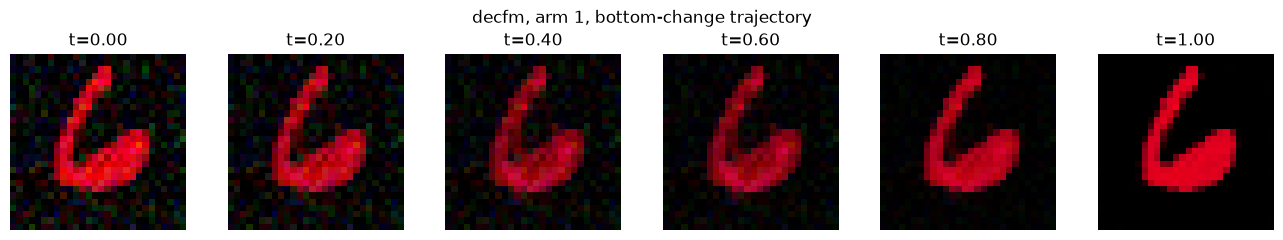

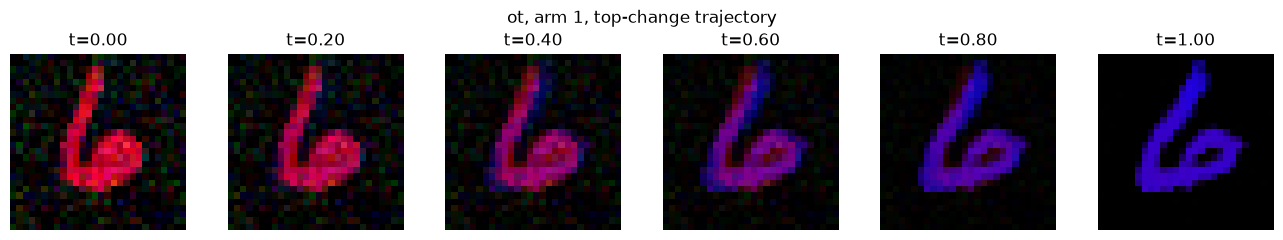

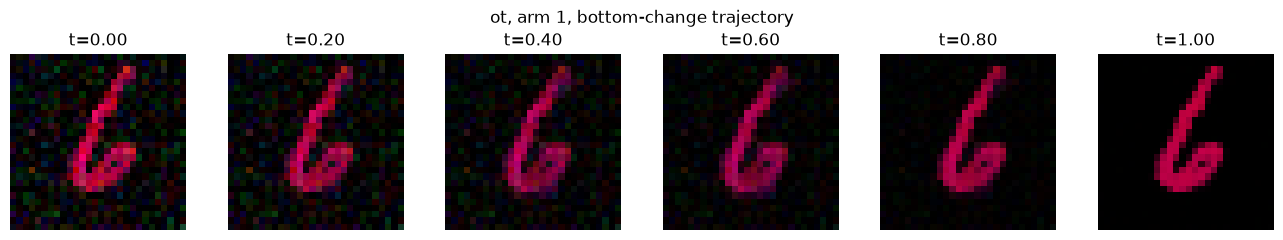

In [8]:
def show_saved_trajectory(method, arm, extreme="top", rank=0, frames=6):
    sequence = trajectories[method][f"arm{arm}"][extreme]["trajectory"][:, rank]
    indices = torch.linspace(0, len(sequence) - 1, frames).long()
    fig, axes = plt.subplots(1, frames, figsize=(2.2 * frames, 2.4))
    for ax, index in zip(axes, indices):
        ax.imshow(sequence[index].permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"t={index.item()/(len(sequence)-1):.2f}")
        ax.axis("off")
    fig.suptitle(f"{method}, arm {arm}, {extreme}-change trajectory")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    show_saved_trajectory(method, arm=1, extreme="top")
    show_saved_trajectory(method, arm=1, extreme="bottom")
